In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.features import obs_to_dfs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
 /opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning:hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.


In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (500, 2000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E5, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE
noise_density = 0.3
noise_max_val = 1e4

In [9]:
mzml_filename = 'Beer_multibeers_1_fullscan1.mzML'
mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                       min_log_intensity=min_log_intensity,
                                       max_log_intensity=max_log_intensity)

2022-03-19 22:04:30.473 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans
2022-03-19 22:04:32.311 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans


In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
    },
    'noise': {
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol
    }
}

Initialise a new DDA environment that tracks the most intense peaks.

In [11]:
max_peaks = 10
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan) -- can be empty

In [12]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

(   intensities  fragmented  excluded
 0          0.0         0.0       0.0
 1          0.0         0.0       0.0
 2          0.0         0.0       0.0
 3          0.0         0.0       0.0
 4          0.0         0.0       0.0
 5          0.0         0.0       0.0
 6          0.0         0.0       0.0
 7          0.0         0.0       0.0
 8          0.0         0.0       0.0
 9          0.0         0.0       0.0,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start        1.0
 elapsed_scans_since_last_ms1     0.0)

In [13]:
observation['valid_actions']

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [14]:
env.features

[]

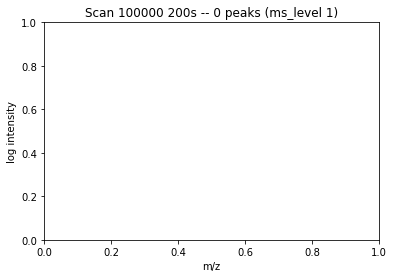

In [15]:
env.render()

Generate 5 ms1 scans

In [16]:
for i in range(5):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -0.1
done False


(   intensities  fragmented  excluded
 0     0.703654         0.0       0.0
 1     0.583337         0.0       0.0
 2     0.559124         0.0       0.0
 3     0.538243         0.0       0.0
 4     0.398019         0.0       0.0
 5     0.357194         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start        6.0
 elapsed_scans_since_last_ms1     0.0)

In [17]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1.])

In [18]:
env.features

[mz=126.02920032278459 rt=202.00000000000003 intensity=43634475.27337151 (0.7036543245258485),
 mz=328.71340003344676 rt=202.00000000000003 intensity=2155275.642335685 (0.5833371672646736),
 mz=268.9762671364238 rt=202.00000000000003 intensity=1176553.8049966027 (0.5591240087683045),
 mz=104.90950050108036 rt=202.00000000000003 intensity=698063.8167562522 (0.538242632223311),
 mz=118.41880010530836 rt=202.00000000000003 intensity=20962.050416411897 (0.39801875835443584),
 mz=166.1580390514465 rt=202.00000000000003 intensity=7554.135461348633 (0.3571940174204596)]

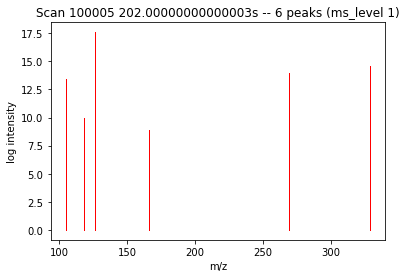

In [19]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [20]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward 0.7996441710694019
done False


(   intensities  fragmented  excluded
 0     0.703654         1.0       0.4
 1     0.583337         0.0       0.0
 2     0.559124         0.0       0.0
 3     0.538243         0.0       0.0
 4     0.398019         0.0       0.0
 5     0.357194         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 1.0
 unfragmented_count               9.0
 excluded_count                   1.0
 unexcluded_count                 9.0
 elapsed_scans_since_start        7.0
 elapsed_scans_since_last_ms1     1.0)

In [21]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1.])

In [22]:
env.features

[mz=126.02920032278459 rt=202.00000000000003 intensity=43634475.27337151 (0.7036543245258485),
 mz=328.71340003344676 rt=202.00000000000003 intensity=2155275.642335685 (0.5833371672646736),
 mz=268.9762671364238 rt=202.00000000000003 intensity=1176553.8049966027 (0.5591240087683045),
 mz=104.90950050108036 rt=202.00000000000003 intensity=698063.8167562522 (0.538242632223311),
 mz=118.41880010530836 rt=202.00000000000003 intensity=20962.050416411897 (0.39801875835443584),
 mz=166.1580390514465 rt=202.00000000000003 intensity=7554.135461348633 (0.3571940174204596)]

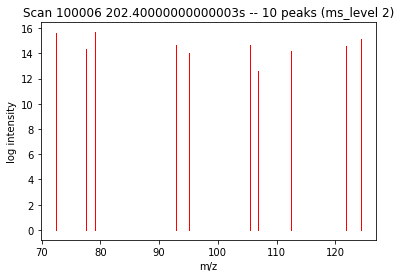

In [23]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [24]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward 0.6853172495133341
done False


(   intensities  fragmented  excluded
 0     0.703654         1.0       0.6
 1     0.583337         1.0       0.6
 2     0.559124         0.0       0.0
 3     0.538243         0.0       0.0
 4     0.398019         0.0       0.0
 5     0.357194         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 2.0
 unfragmented_count               8.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start        8.0
 elapsed_scans_since_last_ms1     2.0)

In [25]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1.])

In [26]:
env.features

[mz=126.02920032278459 rt=202.00000000000003 intensity=43634475.27337151 (0.7036543245258485),
 mz=328.71340003344676 rt=202.00000000000003 intensity=2155275.642335685 (0.5833371672646736),
 mz=268.9762671364238 rt=202.00000000000003 intensity=1176553.8049966027 (0.5591240087683045),
 mz=104.90950050108036 rt=202.00000000000003 intensity=698063.8167562522 (0.538242632223311),
 mz=118.41880010530836 rt=202.00000000000003 intensity=20962.050416411897 (0.39801875835443584),
 mz=166.1580390514465 rt=202.00000000000003 intensity=7554.135461348633 (0.3571940174204596)]

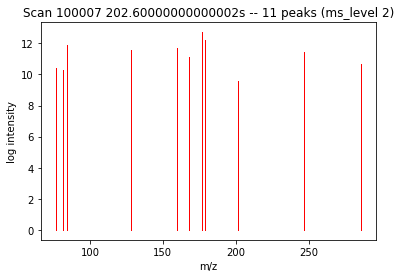

In [27]:
env.render()

Repeat targeting of the same precursor produces negative reward, up to a point

In [28]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward -0.4
reward -0.4
reward -0.4
reward -0.4
reward -0.4
reward -0.4
reward -0.4
reward -0.4
reward -0.4
reward -0.4


In [29]:
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

(   intensities  fragmented  excluded
 0     0.703654        11.0       2.6
 1     0.583337         1.0       2.6
 2     0.559124         0.0       0.0
 3     0.538243         0.0       0.0
 4     0.398019         0.0       0.0
 5     0.357194         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 2.0
 unfragmented_count               8.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start       18.0
 elapsed_scans_since_last_ms1    12.0)

In [30]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1.])

In [31]:
env.features

[mz=126.02920032278459 rt=202.00000000000003 intensity=43634475.27337151 (0.7036543245258485),
 mz=328.71340003344676 rt=202.00000000000003 intensity=2155275.642335685 (0.5833371672646736),
 mz=268.9762671364238 rt=202.00000000000003 intensity=1176553.8049966027 (0.5591240087683045),
 mz=104.90950050108036 rt=202.00000000000003 intensity=698063.8167562522 (0.538242632223311),
 mz=118.41880010530836 rt=202.00000000000003 intensity=20962.050416411897 (0.39801875835443584),
 mz=166.1580390514465 rt=202.00000000000003 intensity=7554.135461348633 (0.3571940174204596)]

Making an invalid move produces negative reward.

In [32]:
action = 9 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -1
done False


(   intensities  fragmented  excluded
 0     0.703654        11.0       2.8
 1     0.583337         1.0       2.8
 2     0.559124         0.0       0.0
 3     0.538243         0.0       0.0
 4     0.398019         0.0       0.0
 5     0.357194         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         1.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 3.0
 unfragmented_count               7.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start       19.0
 elapsed_scans_since_last_ms1    13.0)

In [33]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1.])

In [34]:
env.features

[mz=126.02920032278459 rt=202.00000000000003 intensity=43634475.27337151 (0.7036543245258485),
 mz=328.71340003344676 rt=202.00000000000003 intensity=2155275.642335685 (0.5833371672646736),
 mz=268.9762671364238 rt=202.00000000000003 intensity=1176553.8049966027 (0.5591240087683045),
 mz=104.90950050108036 rt=202.00000000000003 intensity=698063.8167562522 (0.538242632223311),
 mz=118.41880010530836 rt=202.00000000000003 intensity=20962.050416411897 (0.39801875835443584),
 mz=166.1580390514465 rt=202.00000000000003 intensity=7554.135461348633 (0.3571940174204596)]

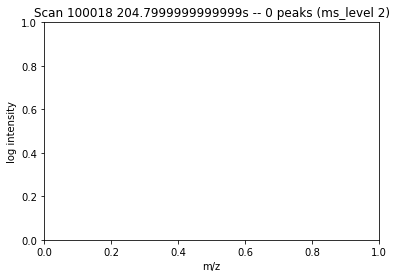

In [35]:
env.render()

Generate lots of MS1 scans

In [36]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -0.1
done False


(   intensities  fragmented  excluded
 0     0.910903         0.0       0.0
 1     0.883344         0.0       0.0
 2     0.879660         0.0       0.0
 3     0.879412         0.0       0.0
 4     0.877597         0.0       0.0
 5     0.869713         0.0       0.0
 6     0.863762         0.0       0.0
 7     0.858802         0.0       0.0
 8     0.856200         0.0       0.0
 9     0.848567         0.0       0.0,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start      119.0
 elapsed_scans_since_last_ms1     0.0)

In [37]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [38]:
env.features

[mz=258.015836816786 rt=244.60000000000045 intensity=7762620911.618532 (0.910903434418427),
 mz=118.69969520721338 rt=244.60000000000045 intensity=3897521760.5398083 (0.8833442696834075),
 mz=116.74639594356695 rt=244.60000000000045 intensity=3554589942.017338 (0.8796602218687236),
 mz=206.35398184754436 rt=244.60000000000045 intensity=3532629303.8223157 (0.8794123310362995),
 mz=116.23577234257475 rt=244.60000000000045 intensity=3375862552.2563844 (0.8775966679862848),
 mz=229.41387172200896 rt=244.60000000000045 intensity=2771968988.9933076 (0.8697129492391855),
 mz=308.2348005078986 rt=244.60000000000045 intensity=2388799214.091896 (0.8637622662300847),
 mz=118.83690442252501 rt=244.60000000000045 intensity=2110196631.625562 (0.8588018788174522),
 mz=104.60900728716693 rt=244.60000000000045 intensity=1977312623.2944279 (0.8562001799511002),
 mz=281.725556105174 rt=244.60000000000045 intensity=1633780711.65103 (0.8485665048392879)]

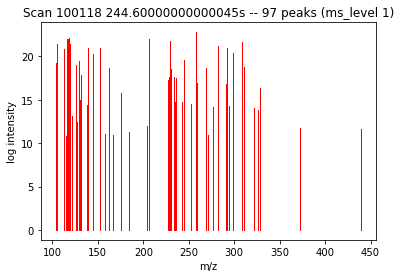

In [39]:
env.render()